# Lab 04 -- Invoice to JSON

Week 6 (content: Multimodal and Image Generation, Lecture 5.1) · Narxoz University

A scanned invoice is a picture. A program that pays it, books it or checks it needs
fields: number, date, seller, BIN, buyer, rows, total. This lab turns pictures into JSON
two ways -- **classic OCR** (Tesseract) and a **vision-language model** (Qwen2-VL-2B) --
and measures where each one breaks, in Kazakh, Russian and English.

**No API key. No cost.** Tesseract and one open model run inside this notebook. The model
download is about 4.4 GB, once per Colab session.

Every invoice is invented (stamped SAMPLE). The same eight invoices exist in three
languages with *identical numbers*, in a clean version and a degraded one (a bad phone
photo), so a difference between languages is not caused by harder digits.

## Setup

1. **Runtime -> Change runtime type -> T4 GPU.** On a CPU the model is far too slow.
2. Run the next cell once. It installs Tesseract (with its Kazakh and Russian language
   data) and the Python packages Colab does not ship with.
3. From Part 1 on, run cells one at a time. Write your prediction down *before* you run
   the cell that reveals the answer.

In [1]:
# Colab only: the Tesseract program, its Kazakh/Russian data, then the Python packages.
import subprocess
import sys

subprocess.run("apt-get -qq update && apt-get -qq install -y tesseract-ocr "
               "tesseract-ocr-kaz tesseract-ocr-rus > /dev/null", shell=True, check=True)
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "pytesseract==0.3.13",
                "transformers==5.18.0", "accelerate==1.15.0"], check=True)
print("installed")

installed


## Part 0 -- the data and the toolbox

The next cell fetches the 48 images (24 invoices, each clean and degraded) and their
answer files from the lab's GitHub repository. `truth/*.json` says what each invoice
*really* contains; the models never see it. The cell after it is the toolbox: read it,
you will use every function in it, but you do not need to edit anything.

In [2]:
import json
import os
import subprocess

REPO_URL = "https://github.com/unreal-kz/lab-04-AI-course.git"
if not os.path.exists("data/manifest.json"):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir("lab-04-AI-course")


def load_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


DOCS = load_json("data/manifest.json")["docs"]
TRUTH = {d["id"]: load_json(f"data/truth/{d['id']}.json") for d in DOCS}
CONDITIONS = ("clean", "degraded")


def image_path(doc, cond):
    return f"data/{cond}/{doc['id']}." + ("png" if cond == "clean" else "jpg")


print(len(DOCS), "documents x", len(CONDITIONS), "conditions =", len(DOCS) * len(CONDITIONS), "images")
print("languages:", sorted({d["lang"] for d in DOCS}))

24 documents x 2 conditions = 48 images
languages: ['en', 'kk', 'ru']


In [3]:
"""Toolbox for Lab 04 -- Invoice to JSON.

This file is the single source of truth for the lab's logic. ``build_notebook.py`` pastes it
verbatim into one notebook cell, and ``reference_run.py`` imports it, so the numbers in the
README come from the same code a student runs. Heavy imports (torch, transformers,
pytesseract) happen inside the functions that need them.
"""

from __future__ import annotations

import difflib
import json
import math
import re
import unicodedata
from collections import Counter
from datetime import date
from typing import Any

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
OCR_LANGS = "kaz+rus+eng"
OCR_PSM = 4  # Tesseract page-segmentation mode: "a single column of text of variable sizes"

# Field names only. No value from any truth file ever reaches a prompt.
PROMPT = (
    "Extract this invoice as JSON with exactly these keys: invoice_number, date (YYYY-MM-DD), "
    "seller_name, seller_bin, buyer_name, items (list of objects with name, qty, unit_price, "
    "amount), total. Numbers must be plain integers. Output JSON only."
)

NUMERIC_FIELDS = ("qty", "unit_price", "amount", "total")
NAME_FIELDS = ("seller_name", "buyer_name", "name")  # "name" = an item name
KAZAKH_FOLD = str.maketrans("ӘәҒғҚқҢңӨөҰұҮүҺһІі", "АаГгКкНнОоУуУуХхИи")
LOOKALIKE_FOLD = str.maketrans("ABCEHKMOPTXYaceopxy", "АВСЕНКМОРТХУасеорху")  # Latin -> identical-looking Cyrillic


# ----------------------------------------------------------------------------- parsing
def parse_model_json(text: str) -> dict[str, Any] | None:
    """Parse a model answer into a dict, tolerating a markdown code fence around it.

    Args:
        text: Raw model output.

    Returns:
        The parsed JSON object, or ``None`` if no JSON object can be recovered.
    """
    body = text.strip()
    body = re.sub(r"^```(?:json)?\s*", "", body)
    body = re.sub(r"\s*```$", "", body)
    for candidate in (body, body[body.find("{"): body.rfind("}") + 1]):
        try:
            value = json.loads(candidate)
        except json.JSONDecodeError:
            continue
        if isinstance(value, dict):
            return value
    return None


def flatten(obj: Any, prefix: str = "") -> dict[str, Any]:
    """Flatten nested dicts and lists into ``{"items.0.qty": 40, ...}``."""
    out: dict[str, Any] = {}
    if isinstance(obj, dict):
        for key, value in obj.items():
            out.update(flatten(value, f"{prefix}{key}."))
    elif isinstance(obj, list):
        for i, value in enumerate(obj):
            out.update(flatten(value, f"{prefix}{i}."))
    else:
        out[prefix.rstrip(".")] = obj
    return out


def leaf(path: str) -> str:
    """Last component of a flattened path: ``items.0.qty`` -> ``qty``."""
    return path.rsplit(".", 1)[-1]


# ----------------------------------------------------------------------------- normalisation
def normalize_date(value: Any) -> Any:
    """Turn ``DD.MM.YYYY``, ``DD/MM/YYYY`` or ``DD-MM-YYYY`` into ISO ``YYYY-MM-DD``.

    Anything else (including an already ISO date) is returned stripped and unchanged.
    """
    if not isinstance(value, str):
        return value
    text = value.strip()
    match = re.fullmatch(r"(\d{1,2})[./-](\d{1,2})[./-](\d{4})", text)
    if match:
        day, month, year = (int(g) for g in match.groups())
        try:
            return date(year, month, day).isoformat()
        except ValueError:  # e.g. 31.02.2026: not a real date, leave it for the comparison to fail
            return text
    return text


def normalize_number(value: Any) -> Any:
    """Read ``1 509 000``, ``"1509000"`` or ``1509000.0`` as the integer 1509000.

    Every non-digit character is dropped, so this is deliberately forgiving.
    Returns the input unchanged when no digit is present.
    """
    if isinstance(value, bool):
        return value
    if isinstance(value, int):
        return value
    if isinstance(value, float) and value.is_integer():
        return int(value)
    if isinstance(value, str):
        digits = re.sub(r"\D", "", value)
        if digits:
            return int(digits)
    return value


def normalize_text(value: Any) -> Any:
    """NFC-normalise, collapse whitespace and strip. Case and Kazakh letters are kept."""
    if not isinstance(value, str):
        return value
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", value)).strip()


def normalize_field(path: str, value: Any) -> Any:
    """Apply the normaliser that matches the field at ``path``."""
    name = leaf(path)
    if name == "date":
        return normalize_date(value)
    if name in NUMERIC_FIELDS:
        return normalize_number(value)
    return normalize_text(value)


# ----------------------------------------------------------------------------- scoring
def score_fields(truth: dict[str, Any], pred: dict[str, Any] | None, *,
                 normalized: bool = True) -> dict[str, bool]:
    """Field-level exact match of a prediction against the truth.

    Every field in the truth is scored; a missing field or a missing row counts as wrong, an
    extra row in the prediction is ignored. ``normalized=False`` compares raw JSON values.

    Args:
        truth: Ground-truth invoice.
        pred: Parsed model answer, or ``None`` when parsing failed (every field is wrong).
        normalized: Apply ``normalize_field`` to both sides before comparing.

    Returns:
        ``{flattened path: matched}`` for every field of the truth.
    """
    truth_flat = flatten(truth)
    pred_flat = flatten(pred) if pred is not None else {}
    hits: dict[str, bool] = {}
    for path, expected in truth_flat.items():
        got = pred_flat.get(path)
        if normalized:
            expected, got = normalize_field(path, expected), normalize_field(path, got)
        hits[path] = got == expected
    return hits


def arithmetic_checks(pred: dict[str, Any] | None) -> dict[str, bool]:
    """The two checks of Lecture 5.1: qty x price = amount per row, and sum of amounts = total.

    These use only the prediction, never the truth, so they can run in production.
    Unreadable numbers make the check fail.
    """
    if pred is None:
        return {"rows_ok": False, "total_ok": False}
    items = pred.get("items")
    rows_ok, amounts = isinstance(items, list) and len(items) > 0, []
    for item in items if isinstance(items, list) else []:
        if not isinstance(item, dict):
            rows_ok = False
            continue
        qty, price, amount = (normalize_number(item.get(k)) for k in ("qty", "unit_price", "amount"))
        if not all(isinstance(v, int) and not isinstance(v, bool) for v in (qty, price, amount)):
            rows_ok = False
            continue
        amounts.append(amount)
        rows_ok = rows_ok and qty * price == amount
    total = normalize_number(pred.get("total"))
    total_ok = isinstance(total, int) and not isinstance(total, bool) and len(amounts) > 0 and sum(amounts) == total
    return {"rows_ok": bool(rows_ok), "total_ok": bool(total_ok)}


def wilson(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score interval for a proportion (95 % for ``z=1.96``).

    Unlike the plain ``p +- 1.96 * sqrt(p(1-p)/n)`` it stays inside [0, 1] and does not collapse
    to zero width when every trial succeeded: 18/18 gives about (0.82, 1.00).
    """
    if n == 0:
        return (0.0, 1.0)
    p = successes / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


# ----------------------------------------------------------------------------- OCR side
def ocr_text(image_path: str, psm: int = OCR_PSM) -> str:
    """Tesseract OCR with Kazakh, Russian and English models.

    Args:
        image_path: Path to the invoice image.
        psm: Tesseract page-segmentation mode. The default (4) reads a ruled table row by row;
            mode 6 treats the page as one block and loses most of the table.
    """
    import pytesseract

    # A path, not a PIL image: pytesseract re-encodes a PIL JPEG (quality 75) before OCR,
    # which would add a second round of compression to the degraded scans.
    return pytesseract.image_to_string(str(image_path), lang=OCR_LANGS, config=f"--psm {psm}")


def _squash(text: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", text)).strip().casefold()


def ocr_found(truth: dict[str, Any], text: str) -> dict[str, bool]:
    """For every truth field: does its value appear in the OCR text at all?

    This is an upper bound for any rule-based parser sitting on top of that OCR text: a field
    that is not in the text cannot be extracted from it. It is not a parse, and a number can
    match by accident (``40`` also occurs inside other numbers' neighbourhoods), so treat small
    differences with care.

    Args:
        truth: Ground-truth invoice.
        text: OCR output for the same image.

    Returns:
        ``{flattened path: found}``.
    """
    squashed = _squash(text)
    found: dict[str, bool] = {}
    for path, value in flatten(truth).items():
        name = leaf(path)
        if name in NUMERIC_FIELDS:
            groups = f"{int(value):,}".split(",")  # 580000 -> ["580", "000"]: found as "580 000" or "580000"
            pattern = r"(?<!\d)" + r"[\s ]?".join(groups) + r"(?!\d)"
            found[path] = re.search(pattern, text) is not None
        elif name == "date":
            shown = date.fromisoformat(str(value)).strftime("%d.%m.%Y")
            found[path] = shown in text
        elif name == "seller_bin":
            found[path] = re.search(rf"(?<!\d){value}(?!\d)", text) is not None
        else:
            found[path] = _squash(str(value)) in squashed
    return found


# ----------------------------------------------------------------------------- VLM side
def pick_device() -> str:
    """``cuda`` if present, else Apple ``mps``, else ``cpu``."""
    import torch

    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def load_vlm(device: str | None = None) -> tuple[Any, Any, str]:
    """Load Qwen2-VL-2B-Instruct in eval mode: float16 on a GPU, float32 on CPU.

    Returns:
        ``(model, processor, device)``.
    """
    import torch
    from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

    device = device or pick_device()
    dtype = torch.float32 if device == "cpu" else torch.float16
    model = Qwen2VLForConditionalGeneration.from_pretrained(MODEL_ID, dtype=dtype).to(device)
    model.eval()
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    return model, processor, device


def vlm_extract(model: Any, processor: Any, image_path: str, *, prompt: str = PROMPT,
                hint: str | None = None, max_new_tokens: int = 512) -> str:
    """Ask the VLM to read one invoice image. Greedy decoding, so the answer is repeatable.

    Args:
        model: Model from ``load_vlm``.
        processor: Processor from ``load_vlm``.
        image_path: Path to the invoice image.
        prompt: Instruction text.
        hint: Optional OCR text appended to the prompt (the hybrid experiment).
        max_new_tokens: Generation budget.

    Returns:
        The raw decoded answer, before any JSON parsing.
    """
    import torch
    from PIL import Image

    text = prompt if hint is None else f"{prompt}\n\nOCR text of the same image (may contain errors):\n{hint}"
    with Image.open(image_path) as img:
        messages = [{"role": "user", "content": [{"type": "image", "image": img.convert("RGB")},
                                                    {"type": "text", "text": text}]}]
        inputs = processor.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt"
        ).to(model.device)
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    new_ids = out[0][inputs["input_ids"].shape[1]:]
    return processor.decode(new_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)


# ----------------------------------------------------------------------------- error analysis
def fold_kazakh(text: str) -> str:
    """Replace each Kazakh-specific letter with its nearest plain Cyrillic one (Қ->К, Ә->А, ...)."""
    return text.translate(KAZAKH_FOLD)


def fold_lookalikes(text: str) -> str:
    """Replace Latin letters that look identical to Cyrillic ones (T, O, A, ...) with the Cyrillic letter."""
    return text.translate(LOOKALIKE_FOLD)


def error_kind(truth_text: str, pred_text: Any) -> str:
    """Why is a name wrong? The first kind that explains it, checked in this order.

    * ``missing``: the model returned no string at all
    * ``script``: the same text once Latin look-alike letters are mapped to Cyrillic
      (``TOO`` typed with Latin letters instead of ``ТОО``)
    * ``kazakh``: the same text once Kazakh-specific letters are mapped to plain Cyrillic
    * ``both``: needs both foldings
    * ``misread``: still different, a genuine reading error or invented text
    """
    if not isinstance(pred_text, str):
        return "missing"
    if truth_text == pred_text:
        return "equal"
    if fold_lookalikes(truth_text) == fold_lookalikes(pred_text):
        return "script"
    if fold_kazakh(truth_text) == fold_kazakh(pred_text):
        return "kazakh"
    if fold_lookalikes(fold_kazakh(truth_text)) == fold_lookalikes(fold_kazakh(pred_text)):
        return "both"
    return "misread"


def char_confusions(truth_text: str, pred_text: str) -> Counter[tuple[str, str]]:
    """Count (true char, read char) pairs where the two strings differ by same-length replacement."""
    pairs: Counter[tuple[str, str]] = Counter()
    matcher = difflib.SequenceMatcher(None, truth_text, pred_text, autojunk=False)
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "replace" and i2 - i1 == j2 - j1:
            pairs.update(zip(truth_text[i1:i2], pred_text[j1:j2]))
    return pairs

## Part 1 -- look before you measure

Eight invoices, each written in Kazakh (`kk`), Russian (`ru`) and English (`en`), each
as a clean render and as a degraded copy (40 % of the resolution, tilted, blurred, heavy
JPEG). Below: the first invoice's truth and both pictures.

inv01_kk truth (first lines):
{
 "invoice_number": "8043",
 "date": "2026-09-29",
 "seller_name": "«Нарынқол Трейд» ЖШС",
 "seller_bin": "101030509027",
 "buyer_name": "«Арай Маркет» ЖШС",
 "items": [
  {
   "name": "Жұмыртқа, 30 дана",
   "qty": 145,
   "unit_price": 1950,
   "amount": 282750
  },
  {
   "name": "Ірімшік, 1 кг",
   "qty": 90,
   "unit_price": 3850,
   "amount": 346500
  },
  {
   "name": "Күнбағыс майы, 5 л",
   "qty": 95,
   "unit_price": 3250,
   "amount": 308750
  },
  {
   "name": "Күріш, 25 кг",
   "qt ...
clean (1100, 760)


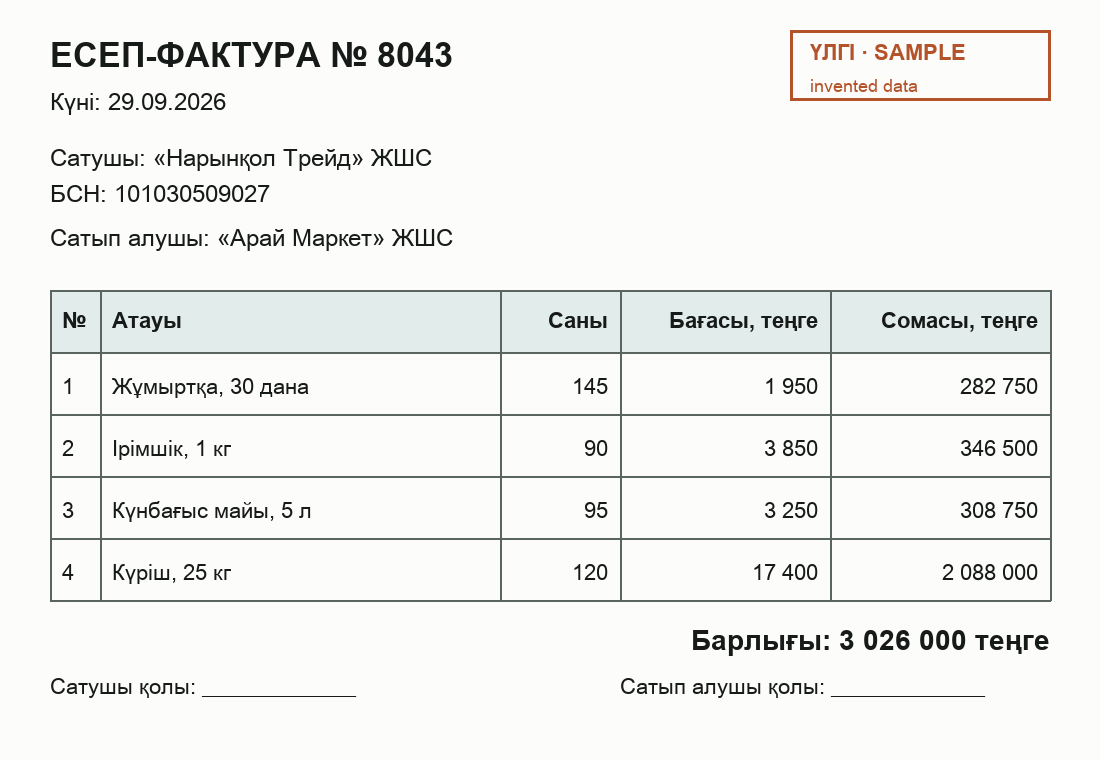

degraded (452, 320)


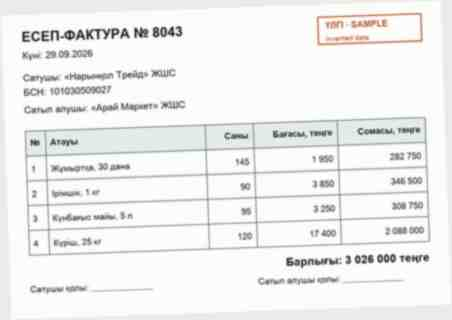

In [4]:
from PIL import Image

try:
    from IPython.display import display
except ImportError:  # running outside a notebook
    display = print

doc = DOCS[0]
print(doc["id"], "truth (first lines):")
print(json.dumps(TRUTH[doc["id"]], ensure_ascii=False, indent=1)[:500], "...")
for cond in CONDITIONS:
    with Image.open(image_path(doc, cond)) as im:
        print(cond, im.size)
        display(im.copy())

✏️ **Predict 1, before you run anything else.** Write down:

1. The numbers are identical in the three languages. On which language will the VLM make
   the most mistakes, and in which fields?

Most of the errors will be in Kazakh, in fields with names (seller_name, buyer_name, product names). The numbers are the same, but the model sees Kazakh letters less often, and she can replace them with Russian ones. The numbers and BIN should be more reliable.

2. When the picture is degraded, which loses more: OCR or the VLM?

If it gets worse, the OCR will lose more. Tesseract is sensitive to blurring, tilt, and low resolution. VLM should degrade more gently.

3. Roughly what percentage of fields will each method get right on the clean images?
   (A guess. Nothing grades it; the point is to compare it with the measurement.)

On clean: upper bound OCR is about 85%, VLM is about 95%.

## Part 2 -- classic OCR

Tesseract returns *text*, not JSON. To get fields out of that text you would still write
rules. So first we measure something simpler and generous: for every field of the truth,
**does its value appear in the OCR text at all?** If it does not, no parser sitting on
top of that text could ever recover it, so this number is an *upper bound* for the whole
OCR approach. (It is not a parse: a number can match by accident.)

Tesseract needs to be told how the page is laid out. Here `psm=4` ("a single column of
text of variable sizes") is used; one of the extension tasks changes it.

In [5]:
import time
from collections import defaultdict

OCR = {}
t0 = time.time()
for doc in DOCS:
    for cond in CONDITIONS:
        text = ocr_text(image_path(doc, cond))
        OCR[(doc["id"], cond)] = {"text": text, "found": ocr_found(TRUTH[doc["id"]], text)}
print(f"OCR on {len(OCR)} images: {time.time() - t0:.0f} s")
print("\nOCR text of", DOCS[0]["id"], "(clean):\n")
print(OCR[(DOCS[0]["id"], "clean")]["text"])

OCR on 48 images: 47 s

OCR text of inv01_kk (clean):

ЕСЕП-ФАКТУРА Мг 8043
invented data

Күні: 29.09.2026

Сатушы: «Нарынқол Трейд» ЖШС
БСН: 101030509027

Сатып алушы: «Арай Маркет» ЖШС

Ме | Атауы Саны Бағасы, теңге Сомасы, теңге
1 Жұмыртқа, 30 дана 145 1 950 282 750
2 |Ірімшік, 1 кг 90 3 850 346 500
3 Күнбағыс майы, 5 л 95 3250 308 750
4 | Күріш, 25 кг 120 17 400 2 088 000

Барлығы: 3 026 000 теңге

Сатушы қолы: Сатып алушы қолы:



In [6]:
def report(label, per_doc):
    """per_doc: {(doc id, condition): {field: True/False}}  ->  accuracy with a 95 % Wilson interval."""
    for cond in CONDITIONS:
        for lang in ("all", "kk", "ru", "en"):
            keys = [(d["id"], cond) for d in DOCS if lang in ("all", d["lang"])]
            k = sum(sum(per_doc[key].values()) for key in keys)
            n = sum(len(per_doc[key]) for key in keys)
            lo, hi = wilson(k, n)
            print(f"{label:10s} {cond:9s} {lang:3s} {k:3d}/{n:3d} = {k / n:.3f}   95% interval [{lo:.2f}, {hi:.2f}]")


report("OCR found", {key: v["found"] for key, v in OCR.items()})

OCR found  clean     all 426/456 = 0.934   95% interval [0.91, 0.95]
OCR found  clean     kk  148/152 = 0.974   95% interval [0.93, 0.99]
OCR found  clean     ru  142/152 = 0.934   95% interval [0.88, 0.96]
OCR found  clean     en  136/152 = 0.895   95% interval [0.84, 0.93]
OCR found  degraded  all   4/456 = 0.009   95% interval [0.00, 0.02]
OCR found  degraded  kk    1/152 = 0.007   95% interval [0.00, 0.04]
OCR found  degraded  ru    3/152 = 0.020   95% interval [0.01, 0.06]
OCR found  degraded  en    0/152 = 0.000   95% interval [0.00, 0.02]


✏️ **Predict 2, before the model runs.** Compare the two approaches. On clean images,
which recovers more fields: this OCR upper bound or the VLM? On degraded images? Write
both answers; you will check them in Part 4.

Clean images: the OCR upper bound will be about 90% and the VLM about 85%. I think OCR will be higher or close to the VLM, because OCR only has to find the value somewhere in the text, but the VLM must give it exactly in the right field.

Degraded images: the OCR upper bound will be about 10% and the VLM about 15%. I think the VLM will find more fields, because OCR text is almost useless on blurry, small images.

## Part 3 -- a vision-language model reads the picture

`Qwen/Qwen2-VL-2B-Instruct` (2.2 billion parameters, Apache-2.0) gets the image and one
instruction (printed below) and has to answer with JSON. The instruction names the
fields but contains no values. Decoding is greedy, so the same image gives the same
answer every time.

The next cell downloads the model (about 4.4 GB) and moves it to the GPU.

In [7]:
model, processor, DEVICE = load_vlm()
print("device:", DEVICE, "| dtype:", model.dtype, "| training mode:", model.training)
if DEVICE == "cpu":
    print("WARNING: no GPU found. Switch the runtime to T4 GPU (Setup, step 1) or this will take hours.")
print("\nprompt:", PROMPT)

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

device: cuda | dtype: torch.float16 | training mode: False

prompt: Extract this invoice as JSON with exactly these keys: invoice_number, date (YYYY-MM-DD), seller_name, seller_bin, buyer_name, items (list of objects with name, qty, unit_price, amount), total. Numbers must be plain integers. Output JSON only.


In [8]:
DEMO = "inv01_kk"  # try another id from DOCS, for example "inv03_ru" or "inv05_en"
demo = next(d for d in DOCS if d["id"] == DEMO)
for cond in CONDITIONS:
    raw = vlm_extract(model, processor, image_path(demo, cond))
    pred = parse_model_json(raw)
    strict = score_fields(TRUTH[DEMO], pred, normalized=False)
    norm = score_fields(TRUTH[DEMO], pred, normalized=True)
    print(f"===== {DEMO} {cond}: strict {sum(strict.values())}/{len(strict)}, "
          f"normalised {sum(norm.values())}/{len(norm)}, arithmetic checks {arithmetic_checks(pred)}")
    print(raw)
    true_flat, pred_flat = flatten(TRUTH[DEMO]), flatten(pred or {})
    for path, ok in norm.items():
        if not ok:
            print(f"  wrong {path}: truth {true_flat[path]!r}  model {pred_flat.get(path)!r}")

===== inv01_kk clean: strict 17/22, normalised 18/22, arithmetic checks {'rows_ok': True, 'total_ok': True}
```json
{
  "invoice_number": "8043",
  "date": "29.09.2026",
  "seller_name": "Нарынкол Трейд",
  "seller_bin": "101030509027",
  "buyer_name": "Арай Маркет",
  "items": [
    {
      "name": "Жумыртка, 30 дана",
      "qty": 145,
      "unit_price": 1950,
      "amount": 282750
    },
    {
      "name": "Иримшік, 1 кг",
      "qty": 90,
      "unit_price": 3850,
      "amount": 346500
    },
    {
      "name": "Күнбағыс майы, 5 л",
      "qty": 95,
      "unit_price": 3250,
      "amount": 308750
    },
    {
      "name": "Күріш, 25 кг",
      "qty": 120,
      "unit_price": 17400,
      "amount": 2088000
    }
  ],
  "total": 3026000
}
```
  wrong seller_name: truth '«Нарынқол Трейд» ЖШС'  model 'Нарынкол Трейд'
  wrong buyer_name: truth '«Арай Маркет» ЖШС'  model 'Арай Маркет'
  wrong items.0.name: truth 'Жұмыртқа, 30 дана'  model 'Жумыртка, 30 дана'
  wrong items.1.name: 

✏️ **Look at the mistakes above, for both pictures.** What kinds are there: a wrong
digit, a wrong letter, an invented word, a missing field, text that is not valid JSON?
When the picture is blurry, does the model leave a field empty or fill it with something
plausible? Which is more dangerous for a payment system?

What kinds of mistakes? On the clean image the model made letter mistakes (Kazakh қ, ұ, і replaced with к, у, и). On the degraded image there are more kinds: invented words (for example "Жилетка" instead of "Жұмыртқа"), wrong digits (3850 became 34650), a lost zero (2088000 became 208800) and extra zeros in the total (302600000 instead of 3026000). The JSON was always valid and no field was left empty.

Empty or plausible? When the picture is blurry, the model does not leave a field empty. It fills it with something that looks plausible.

Which is more dangerous? The plausible wrong value. An empty field is easy to see, and a system can send the invoice to a person. A wrong value like a total 100 times bigger looks normal and can be paid. Here the arithmetic check caught the number errors, but it cannot catch a wrong name like "Жилетка", because names have no arithmetic.

Now the whole set: 48 images, one after another. This is the slow cell; the counter
updates as it goes.

In [9]:
RESULTS = {}
t0 = time.time()
for i, doc in enumerate(DOCS, 1):
    for cond in CONDITIONS:
        raw = vlm_extract(model, processor, image_path(doc, cond))
        pred = parse_model_json(raw)
        RESULTS[(doc["id"], cond)] = {
            "raw": raw, "pred": pred,
            "strict": score_fields(TRUTH[doc["id"]], pred, normalized=False),
            "norm": score_fields(TRUTH[doc["id"]], pred, normalized=True),
            "arith": arithmetic_checks(pred),
        }
    print(f"{i}/{len(DOCS)} documents, {time.time() - t0:.0f} s", end="\r")
print(f"\ndone in {time.time() - t0:.0f} s; answers that were not valid JSON: "
      f"{sum(v['pred'] is None for v in RESULTS.values())}")

24/24 documents, 514 s
done in 514 s; answers that were not valid JSON: 6


## Part 4 -- what the numbers say

Two ways to score a field. **Strict**: the JSON value must equal the truth exactly.
**Normalised**: dates are first converted to `YYYY-MM-DD`, numbers read as integers,
spaces tidied. Look at the date: the invoice *prints* `03.10.2026`, the truth stores
`2026-10-03`, and the prompt asked for ISO. Whether that counts as a reading error is a
choice you are making when you pick the scorer.

The percentage is accompanied by a 95 % Wilson interval. With so few documents the
interval is often wide: two methods whose intervals overlap are not yet shown to differ.

In [10]:
report("VLM strict", {key: v["strict"] for key, v in RESULTS.items()})
print()
report("VLM norm", {key: v["norm"] for key, v in RESULTS.items()})

VLM strict clean     all 374/456 = 0.820   95% interval [0.78, 0.85]
VLM strict clean     kk  103/152 = 0.678   95% interval [0.60, 0.75]
VLM strict clean     ru  130/152 = 0.855   95% interval [0.79, 0.90]
VLM strict clean     en  141/152 = 0.928   95% interval [0.88, 0.96]
VLM strict degraded  all 190/456 = 0.417   95% interval [0.37, 0.46]
VLM strict degraded  kk   77/152 = 0.507   95% interval [0.43, 0.58]
VLM strict degraded  ru   18/152 = 0.118   95% interval [0.08, 0.18]
VLM strict degraded  en   95/152 = 0.625   95% interval [0.55, 0.70]

VLM norm   clean     all 397/456 = 0.871   95% interval [0.84, 0.90]
VLM norm   clean     kk  111/152 = 0.730   95% interval [0.65, 0.79]
VLM norm   clean     ru  138/152 = 0.908   95% interval [0.85, 0.94]
VLM norm   clean     en  148/152 = 0.974   95% interval [0.93, 0.99]
VLM norm   degraded  all 204/456 = 0.447   95% interval [0.40, 0.49]
VLM norm   degraded  kk   84/152 = 0.553   95% interval [0.47, 0.63]
VLM norm   degraded  ru   20/152 

✏️ **Compare with Predict 1 and Predict 2.** Where were you right, where were you wrong,
and by how much? Was the language effect what you expected, given that the numbers are
identical in all three?

**Answers**

Where I was right.

Predict 1: Kazakh was the worst language on clean images (73.0%, against 90.8% for Russian and 97.4% for English). I also said OCR would lose more when the picture is degraded. This was right: OCR went from 93.4% to 0.9%, the VLM from 87.1% to 44.7%.
Predict 2: On clean images OCR was higher than the VLM (93.4% against 87.1%). On degraded images the VLM was better (44.7% against 0.9%).

Where I was wrong, and by how much.

My guess for OCR on clean was 85%, the real number is 93.4% (8 points too low). My guess for the VLM on clean was 95%, the real number is 87.1% (8 points too high).
In Predict 2 I guessed 15% for the VLM on degraded images. The real number is 44.7%, so I was too pessimistic by about 30 points. For OCR I guessed 10%, the real number is 0.9%.
I thought the errors would be mostly in the name fields. I checked this by field type (next cell): the names were the main problem, as I thought.

Was the language effect what I expected?
Only on clean images. Kazakh was the worst, and the intervals of Kazakh and English do not overlap, so this is a real difference, not luck. The numbers are the same in all three languages, so the difference comes from the text and the letters, not from the digits.
On degraded images it was different. Russian was the worst (13.2%), and Kazakh (55.3%) and English (65.8%) were much better. I did not expect this. I do not know the reason, and I did not test it.

In [11]:
def by_field(per_doc, cond):
    totals = defaultdict(lambda: [0, 0])
    for (doc_id, c), hits in per_doc.items():
        if c == cond:
            for path, ok in hits.items():
                totals[leaf(path)][0] += ok
                totals[leaf(path)][1] += 1
    return totals


ocr_hits = {key: v["found"] for key, v in OCR.items()}
vlm_hits = {key: v["norm"] for key, v in RESULTS.items()}
for cond in CONDITIONS:
    print(f"--- {cond}:  field type     OCR found   VLM normalised")
    o, v = by_field(ocr_hits, cond), by_field(vlm_hits, cond)
    for name in o:
        print(f"    {name:15s} {o[name][0]:3d}/{o[name][1]:<3d}     {v[name][0]:3d}/{v[name][1]:<3d}")

--- clean:  field type     OCR found   VLM normalised
    invoice_number   24/24       24/24 
    date             24/24       24/24 
    seller_name      20/24        9/24 
    seller_bin       24/24       24/24 
    buyer_name       24/24        9/24 
    name             52/78       52/78 
    qty              78/78       75/78 
    unit_price       78/78       78/78 
    amount           78/78       78/78 
    total            24/24       24/24 
--- degraded:  field type     OCR found   VLM normalised
    invoice_number    1/24       18/24 
    date              0/24       18/24 
    seller_name       0/24        4/24 
    seller_bin        0/24       13/24 
    buyer_name        0/24        4/24 
    name              0/78        2/78 
    qty               0/78       44/78 
    unit_price        0/78       45/78 
    amount            0/78       40/78 
    total             3/24       16/24 


Field types. On clean images the VLM reads numbers, BIN, invoice number and date almost perfectly (only 3 of 78 qty fields are wrong). Almost all of its errors are in names: 56 of the 59 wrong fields. So my guess from Predict 1, that names would be the problem, was right. OCR finds the company names more often than the VLM (seller 20/24 against 9/24, buyer 24/24 against 9/24).

On degraded images the names are almost lost (10 of 126 correct), and the numbers also fall to about 55%. The total is right in only 16 of 24 documents.

| | Clean | Degraded |
|---|---|---|
| OCR upper bound | 426/456 = 0.934 [0.91, 0.95] | 4/456 = 0.009 [0.00, 0.02] |
| VLM (normalised) | 397/456 = 0.871 [0.84, 0.90] | 204/456 = 0.447 [0.40, 0.49] |

### A cheap safety net: arithmetic checks

Lecture 5.1: an invoice has to add up. For every row `qty x unit_price = amount`, and the
amounts must sum to the `total`. These checks use only the model's own answer, never the
truth, so they could run in production. How many wrong totals do they catch, and how
many right totals do they wrongly flag?



In [12]:
def gate_ok(key):
    return RESULTS[key]["arith"]["rows_ok"] and RESULTS[key]["arith"]["total_ok"]


for cond in CONDITIONS:
    keys = [(d["id"], cond) for d in DOCS]
    wrong_total = [k for k in keys if not RESULTS[k]["norm"]["total"]]
    right_total = [k for k in keys if RESULTS[k]["norm"]["total"]]
    passed = [k for k in keys if gate_ok(k)]
    print(f"{cond}: wrong totals {len(wrong_total)}, caught {sum(not gate_ok(k) for k in wrong_total)}; "
          f"right totals {len(right_total)}, wrongly flagged {sum(not gate_ok(k) for k in right_total)}; "
          f"passed the checks {len(passed)}, of those with every field correct "
          f"{sum(all(RESULTS[k]['norm'].values()) for k in passed)}")

clean: wrong totals 0, caught 0; right totals 24, wrongly flagged 1; passed the checks 23, of those with every field correct 8
degraded: wrong totals 8, caught 8; right totals 16, wrongly flagged 14; passed the checks 2, of those with every field correct 0


Clean images: 0 wrong totals, so nothing to catch. 24 right totals, 1 flagged. 23 documents passed the checks, but only 8 of them had every field correct.
Degraded images: 8 wrong totals, all 8 caught. 16 right totals, 14 flagged. 2 documents passed the checks, and none of them had every field correct.

Would I let the checks approve a payment alone? No. The checks only see numbers that must agree with each other. They cannot see a wrong company name, and 15 of the 23 clean documents that passed had wrong fields (names). On degraded images they catch every wrong total, but they also flag almost every document, so they work well as a trigger for human review, not as an approval.

### Which letters go wrong?

For every wrong name field the cell below says *why*, using the first explanation that
fits: `script` (Latin look-alike letters inside Cyrillic text), `kazakh` (Kazakh-specific
letters replaced by plain Cyrillic ones), `both`, `misread` (still different: a real
reading error or invented text) or `missing` (no string at all). Then it lists the most
frequent (true letter -> letter the model wrote) pairs with their Unicode code points,
because two letters that look identical on screen can be different characters.

In [13]:
for cond in CONDITIONS:
    for lang in ("kk", "ru", "en"):
        kinds, pairs = Counter(), Counter()
        for doc in (d for d in DOCS if d["lang"] == lang):
            key = (doc["id"], cond)
            t, p = flatten(TRUTH[doc["id"]]), flatten(RESULTS[key]["pred"] or {})
            for path, ok in RESULTS[key]["norm"].items():
                if ok or leaf(path) not in NAME_FIELDS:
                    continue
                want, got = normalize_text(t[path]), normalize_text(p.get(path))
                kinds[error_kind(want, got)] += 1
                if isinstance(got, str):
                    pairs.update(char_confusions(want, got))
        print(f"{cond}/{lang}: wrong names {sum(kinds.values())}  kinds {dict(kinds)}")
        for (a, b), n in pairs.most_common(6):
            print(f"      {a} (U+{ord(a):04X}) -> {b} (U+{ord(b):04X})  x{n}")

clean/kk: wrong names 38  kinds {'misread': 28, 'kazakh': 10}
      қ (U+049B) -> к (U+043A)  x11
      ұ (U+04B1) -> ү (U+04AF)  x6
      ұ (U+04B1) -> у (U+0443)  x4
      І (U+0406) -> И (U+0418)  x3
      і (U+0456) -> и (U+0438)  x3
      Қ (U+049A) -> К (U+041A)  x3
clean/ru: wrong names 14  kinds {'script': 14}
      О (U+041E) -> O (U+004F)  x28
      Т (U+0422) -> T (U+0054)  x14
clean/en: wrong names 4  kinds {'misread': 4}
degraded/kk: wrong names 42  kinds {'misread': 41, 'missing': 1}
      қ (U+049B) -> к (U+043A)  x3
      Қ (U+049A) -> К (U+041A)  x3
      қ (U+049B) -> д (U+0434)  x3
      ұ (U+04B1) -> у (U+0443)  x3
      ү (U+04AF) -> у (U+0443)  x2
      ы (U+044B) -> и (U+0438)  x2
degraded/ru: wrong names 42  kinds {'missing': 32, 'misread': 10}
      О (U+041E) -> O (U+004F)  x4
      Т (U+0422) -> T (U+0054)  x2
      ы (U+044B) -> и (U+0438)  x1
      М (U+041C) -> м (U+043C)  x1
      к (U+043A) -> х (U+0445)  x1
      Г (U+0413) -> г (U+0433)  x1
degraded/en

Most frequent letter confusions on Kazakh invoices (clean):

қ (U+049B) → к (U+043A), 11 times
ұ (U+04B1) → ү (U+04AF), 6 times
ұ (U+04B1) → у (U+0443), 4 times

Reading or knowledge of the language? I think it is both. ұ → ү looks like a reading problem, because the two letters are very similar. қ → к and ұ → у look more like a language problem, because the model replaces a Kazakh letter with a Russian one that is more common, even on a clean picture. But I did not prove this.

Experiment: give the model the OCR text of the same image as a hint (OCR reads Kazakh letters well). If the model then keeps the Kazakh letters, it could read them and the problem was in the language, not in the reading.

## Part 5 -- Which Pipeline

I would use the VLM first, then arithmetic checks, and send every document with a wrong check, a low-quality scan or a name field to a person. I would put an image quality check in front of it, because on bad photos the VLM is wrong in more than half of the fields, and OCR is almost useless.


## Declaration of using AI

I used Claude (Anthropic) as a study helper for this lab. I asked it to explain in simple words what the lab is about and what each part of the notebook does.

It also gave me a step-by-step plan for the lab. It helped me understand the results, for example why the VLM made many mistakes in Kazakh names, why the arithmetic checks flagged almost all degraded documents, and why қ became к.

I ran all the cells myself in Google Colab, and all numbers in my report come from my own run.

## What you hand in

One page, submitted to Canvas as this notebook (*File -> Download -> .ipynb*) after you
have run every cell and answered every ✏️ prompt above.

1. Your Predict 1 and Predict 2, and one sentence each on what the measurement showed.
2. One small table from Part 4: OCR upper bound and VLM (normalised) accuracy on clean
   and on degraded images, all languages together, with the intervals.
3. The three most frequent letter confusions on Kazakh invoices, and one sentence: is
   this a *reading* problem or a *knowledge of the language* problem? Name an experiment
   that would tell the two apart.
4. The arithmetic checks: how many wrong totals did they catch, how many right totals did
   they flag, and would you let them approve a payment on their own?
5. One sentence: for scanned invoices like these, which pipeline would you ship, and what
   would you put in front of it?